ขนาดของข้อมูลต้นฉบับ: (500, 50)
ขนาดของข้อมูลหลังทำ PCA: (500, 10)
สัดส่วนเพศในชุดข้อมูล -> หญิง (0): 251, ชาย (1): 249


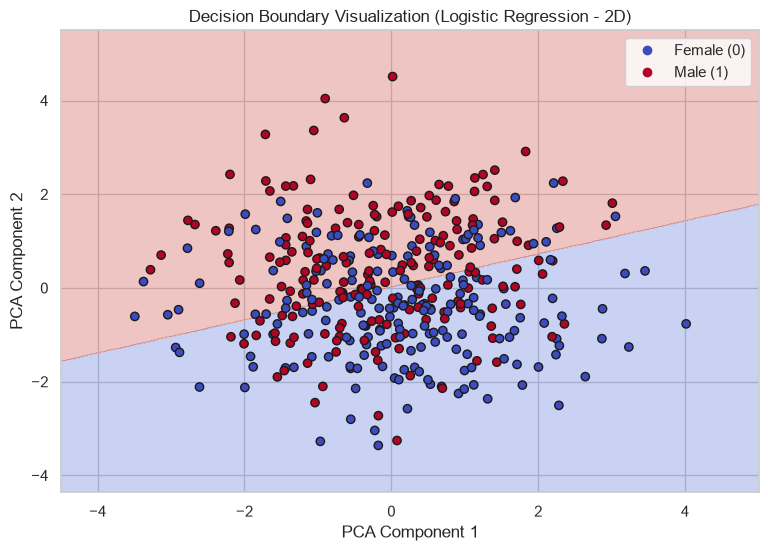

ฝึกสอนแบบจำลอง Logistic Regression เรียบร้อยแล้ว


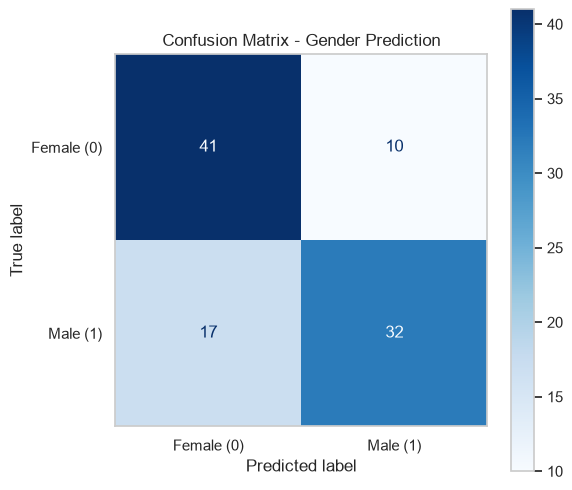

=== สรุปผลการประเมินประสิทธิภาพ (Classification Metrics) ===
Accuracy  : 0.7300
Precision : 0.7619
Recall    : 0.6531
F1-Score  : 0.7033


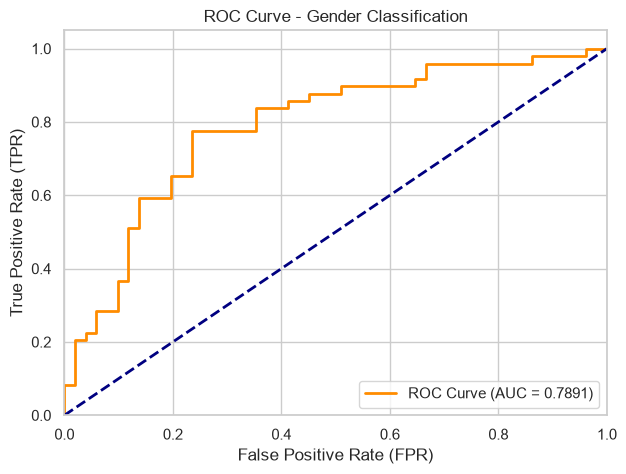

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
     accuracy_score, precision_score, recall_score, f1_score,
     confusion_matrix, ConfusionMatrixDisplay,roc_curve, auc
)

sns.set_theme(style="whitegrid")
np.random.seed(42)
n_samples = 500
n_features = 50

X_raw = np.random.randn(n_samples, n_features)
true_weights = np.random.randn(n_features)
probs = 1 / (1 + np.exp(-np.dot(X_raw, true_weights)))
gender_labels = (probs > 0.5).astype(int)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_raw)

print(f"ขนาดของข้อมูลต้นฉบับ: {X_raw.shape}")
print(f"ขนาดของข้อมูลหลังทำ PCA: {X_pca.shape}")
print(f"สัดส่วนเพศในชุดข้อมูล -> หญิง (0): {np.sum(gender_labels == 0)}, ชาย (1): {np.sum(gender_labels == 1)}")

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_pca[:, :2], gender_labels, test_size=0.2, random_state=42
)

model_2d = LogisticRegression()
model_2d.fit(X_train_2d, y_train_2d)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))


Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_2d, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Decision Boundary Visualization (Logistic Regression - 2D)')
plt.legend(handles=scatter.legend_elements()[0], labels=['Female (0)', 'Male (1)'])
plt.show()



X_train, X_test, y_train, y_test = train_test_split(
    X_pca, gender_labels, test_size=0.2, random_state=42
)


model_gender = LogisticRegression()
model_gender.fit(X_train, y_train)


y_pred = model_gender.predict(X_test)
y_prob = model_gender.predict_proba(X_test)[:, 1]

print("ฝึกสอนแบบจำลอง Logistic Regression เรียบร้อยแล้ว")



cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Female (0)', 'Male (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix - Gender Prediction')
plt.grid(False)
plt.show()


acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== สรุปผลการประเมินประสิทธิภาพ (Classification Metrics) ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")


fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - Gender Classification')
plt.legend(loc="lower right")
plt.show()
